Imports & Setup

In [2]:
import os, glob, shutil, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_ROOT = "/content/drive/MyDrive/smart_building_anomaly"
ZIP_SEARCH_DIRS = [
    PROJECT_ROOT,
    "/content/drive/MyDrive",
    "/content"
]
EXTRACT_DIR = "/content/sharjah_final"
DB_PATH = f"{PROJECT_ROOT}/db/sharjah.db"

os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("✅ Drive mounted")
print(f"Drive accessible: {os.path.exists('/content/drive/MyDrive')}")

Mounted at /content/drive
✅ Drive mounted
Drive accessible: True


Locate + Extract Zip (robust)

In [7]:
import subprocess

zip_candidates = subprocess.run(
    ["find", "/content/drive/MyDrive", "-iname", "*.zip"],
    capture_output=True, text=True
).stdout.strip().splitlines()

if not zip_candidates:
    raise FileNotFoundError(
        "No zip files found anywhere in your Drive. "
        "Upload the Sharjah dataset zip to Drive first, then rerun this cell."
    )

print("Found zip(s) in Drive:")
for i, p in enumerate(zip_candidates):
    size_mb = os.path.getsize(p) / 1e6
    print(f"  [{i}] {p}  ({size_mb:.1f} MB)")

ZIP_PATH = "/content/drive/MyDrive/12750891.zip"
print("\nUsing: " + ZIP_PATH)

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

try:
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        bad_file = z.testzip()
        if bad_file:
            raise zipfile.BadZipFile("Corrupt file inside zip: " + str(bad_file))
        z.extractall(EXTRACT_DIR)
    print("Extraction complete")
except zipfile.BadZipFile as e:
    msg = ("Zip extraction failed - file may be corrupted or incompletely "
           "downloaded. Re-download and retry. Error: " + str(e))
    raise RuntimeError(msg)

macosx_dir = os.path.join(EXTRACT_DIR, "__MACOSX")
if os.path.exists(macosx_dir):
    shutil.rmtree(macosx_dir)

Found zip(s) in Drive:
  [0] /content/drive/MyDrive/ashrae-energy-prediction.zip  (397.1 MB)
  [1] /content/drive/MyDrive/12750891.zip  (0.4 MB)

Using: /content/drive/MyDrive/12750891.zip
Extraction complete


In [9]:
import tarfile

inner_zip = os.path.join(EXTRACT_DIR, "Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0.zip")
inner_targz = os.path.join(EXTRACT_DIR, "Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0.tar.gz")

if os.path.exists(inner_zip):
    print("Extracting inner zip: " + inner_zip)
    with zipfile.ZipFile(inner_zip, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Inner zip extracted")
elif os.path.exists(inner_targz):
    print("Extracting inner tar.gz: " + inner_targz)
    with tarfile.open(inner_targz, "r:gz") as t:
        t.extractall(EXTRACT_DIR)
    print("Inner tar.gz extracted")
else:
    raise FileNotFoundError("Neither inner zip nor tar.gz found in " + EXTRACT_DIR)

macosx_dir = os.path.join(EXTRACT_DIR, "__MACOSX")
if os.path.exists(macosx_dir):
    shutil.rmtree(macosx_dir)

print("\nUpdated tree:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "  " * depth
    print(indent + os.path.basename(root) + "/")
    for f in files[:5]:
        print(indent + "  " + f)
    if len(files) > 5:
        print(indent + "  ... (" + str(len(files) - 5) + " more files)")

Extracting inner zip: /content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0.zip
Inner zip extracted

Updated tree:
sharjah_final/
  Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0.tar.gz
  Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0.zip
  Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0/
    README.md
    Watt W/
      2024-06-21-17-00 Chronograf Data Kettle.csv
      2024-06-21-16-58 Chronograf Data Printer.csv
      2024-06-21-16-57 Chronograf Data Coffee Machine.csv
      2024-06-21-16-58 Chronograf Data Microwave.csv
      2024-06-21-17-00 Chronograf Data Fridge.csv
      ... (3 more files)
    Current A/
      Updated from Januray 1st to June 20nd
      2024-06-21-16-41 Chronograf Data Printer.csv
      2024-06-21-16-42 Chronograf Data Desktop.csv
      2024-06-21-16-41 Ch

Auto-detect the real data root (handles nested folders)

In [10]:
def find_data_root(extract_dir, required_subdirs=("Watt W", "Temperature", "Humidity", "Motion")):
    for root, dirs, files in os.walk(extract_dir):
        if all(any(d.lower() == req.lower() for d in dirs) for req in required_subdirs):
            return root
    return None

BASE = find_data_root(EXTRACT_DIR)

if BASE is None:
    print("Could not auto-locate data root. Folder structure found:")
    for root, dirs, files in os.walk(EXTRACT_DIR):
        depth = root.replace(EXTRACT_DIR, "").count(os.sep)
        indent = "  " * depth
        print(indent + os.path.basename(root) + "/")
        for f in files[:5]:
            print(indent + "  " + f)
    raise FileNotFoundError("Data root not found - inspect structure above.")

print("Data root located: " + BASE)

def resolve_subdir(base, name):
    for d in os.listdir(base):
        if d.lower() == name.lower():
            return os.path.join(base, d)
    return None

SUBDIRS = {
    "watt": resolve_subdir(BASE, "Watt W"),
    "temp": resolve_subdir(BASE, "Temperature"),
    "humidity": resolve_subdir(BASE, "Humidity"),
    "motion": resolve_subdir(BASE, "Motion"),
}
print("Resolved subdirectories:", SUBDIRS)
missing = [k for k, v in SUBDIRS.items() if v is None]
if missing:
    raise FileNotFoundError("Missing expected subdirectories: " + str(missing))

Data root located: /content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0
Resolved subdirectories: {'watt': '/content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0/Watt W', 'temp': '/content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0/Temperature', 'humidity': '/content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0/Humidity', 'motion': '/content/sharjah_final/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure-2.0/Motion'}


Generic robust CSV loader

In [11]:
def load_stream(dir_path, value_col, name_col):
    """Generic loader used by all four streams — dedupes the repeated logic."""
    dfs = []
    csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"❌ No CSVs found in {dir_path}")

    for f in csv_files:
        fname = os.path.basename(f)
        if "GENERAL" in fname.upper():
            label = "GENERAL"
        else:
            label = fname.split("Data")[-1].replace(".csv", "").strip()
            if not label or label == fname:
                label = fname.replace(".csv", "").strip()

        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"⚠️ Skipping unreadable file {fname}: {e}")
            continue

        if df.shape[1] < 2:
            print(f"⚠️ Skipping malformed file {fname} (unexpected column count: {df.shape[1]})")
            continue

        df = df.iloc[:, :2]
        df.columns = ["timestamp", value_col]
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
        df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
        df[name_col] = label
        df = df.dropna(subset=["timestamp", value_col])
        dfs.append(df)

    if not dfs:
        raise ValueError(f"❌ All files in {dir_path} failed to load cleanly")

    return pd.concat(dfs, ignore_index=True).sort_values("timestamp").reset_index(drop=True)

Load all four streams

In [12]:
df_power    = load_stream(SUBDIRS["watt"],     "power_W",      "appliance")
df_temp     = load_stream(SUBDIRS["temp"],     "temp_C",       "location")
df_humidity = load_stream(SUBDIRS["humidity"], "humidity_pct", "location")
df_motion   = load_stream(SUBDIRS["motion"],   "motion_value", "location")

print("✅ All 4 streams loaded")
for name, df in [("Power", df_power), ("Temperature", df_temp),
                  ("Humidity", df_humidity), ("Motion", df_motion)]:
    print(f"  {name:12s}: {df.shape[0]:>7} rows | "
          f"{df['timestamp'].min()} → {df['timestamp'].max()}")

✅ All 4 streams loaded
  Power       :    2378 rows | 2023-12-21 12:00:00+00:00 → 2024-06-20 10:12:00+00:00
  Temperature :    1058 rows | 2024-01-01 10:12:00+00:00 → 2024-06-20 10:12:00+00:00
  Humidity    :    1080 rows | 2024-01-01 10:12:00+00:00 → 2024-06-20 10:12:00+00:00
  Motion      :    1082 rows | 2024-01-01 10:12:00+00:00 → 2024-06-20 10:12:00+00:00


Data Quality Report

In [13]:
print("=" * 55)
print("       SHARJAH 2024 DATASET — QUALITY REPORT")
print("=" * 55)

print("\n📊 POWER (Watt W)")
print(f"  Total records   : {len(df_power)}")
print(f"  Appliances      : {df_power['appliance'].nunique()} -> {list(df_power['appliance'].unique())}")
print(f"  Date range      : {df_power['timestamp'].min().date()} → {df_power['timestamp'].max().date()}")
print(f"  Power range     : {df_power['power_W'].min():.2f}W → {df_power['power_W'].max():.2f}W")

print("\n🌡️  TEMPERATURE")
print(f"  Total records   : {len(df_temp)}")
print(f"  Locations       : {list(df_temp['location'].unique())}")
print(f"  Temp range      : {df_temp['temp_C'].min():.2f}°C → {df_temp['temp_C'].max():.2f}°C")

print("\n💧 HUMIDITY")
print(f"  Total records   : {len(df_humidity)}")
print(f"  Locations       : {list(df_humidity['location'].unique())}")
print(f"  Humidity range  : {df_humidity['humidity_pct'].min():.2f}% → {df_humidity['humidity_pct'].max():.2f}%")

print("\n🚶 MOTION / OCCUPANCY")
print(f"  Total records   : {len(df_motion)}")
print(f"  Locations       : {list(df_motion['location'].unique())}")

print("\n✅ All 4 data streams loaded successfully")
print("=" * 55)


       SHARJAH 2024 DATASET — QUALITY REPORT

📊 POWER (Watt W)
  Total records   : 2378
  Appliances      : 8 -> ['GENERAL', 'Fridge', 'Microwave', 'Desktop', 'Printer', 'Water Dispenser', 'Coffee Machine', 'Kettle']
  Date range      : 2023-12-21 → 2024-06-20
  Power range     : 0.00W → 3585.00W

🌡️  TEMPERATURE
  Total records   : 1058
  Locations       : ['Lab', 'Mailroom', '2024-06-21-16-31 Kitchen']
  Temp range      : 19.77°C → 25.50°C

💧 HUMIDITY
  Total records   : 1080
  Locations       : ['Kitchen', 'Mailroom', 'Lab']
  Humidity range  : 41.07% → 85.66%

🚶 MOTION / OCCUPANCY
  Total records   : 1082
  Locations       : ['Mailroom', 'Kitchen', 'Lab Open colsed door', 'Lab Motion']

✅ All 4 data streams loaded successfully


Save to SQLite (with verification)


In [14]:
conn = sqlite3.connect(DB_PATH)
try:
    df_power.to_sql("power_consumption", conn, if_exists="replace", index=False)
    df_temp.to_sql("temperature", conn, if_exists="replace", index=False)
    df_humidity.to_sql("humidity", conn, if_exists="replace", index=False)
    df_motion.to_sql("motion", conn, if_exists="replace", index=False)
    conn.commit()
finally:
    conn.close()

conn = sqlite3.connect(DB_PATH)
for table in ["power_consumption", "temperature", "humidity", "motion"]:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {table}", conn).iloc[0, 0]
    print(f"✅ {table}: {count} rows saved")
conn.close()

print(f"\n📁 Database saved to: {DB_PATH}")

✅ power_consumption: 2378 rows saved
✅ temperature: 1058 rows saved
✅ humidity: 1080 rows saved
✅ motion: 1082 rows saved

📁 Database saved to: /content/drive/MyDrive/smart_building_anomaly/db/sharjah.db


Sprint 1 Summary Visualization

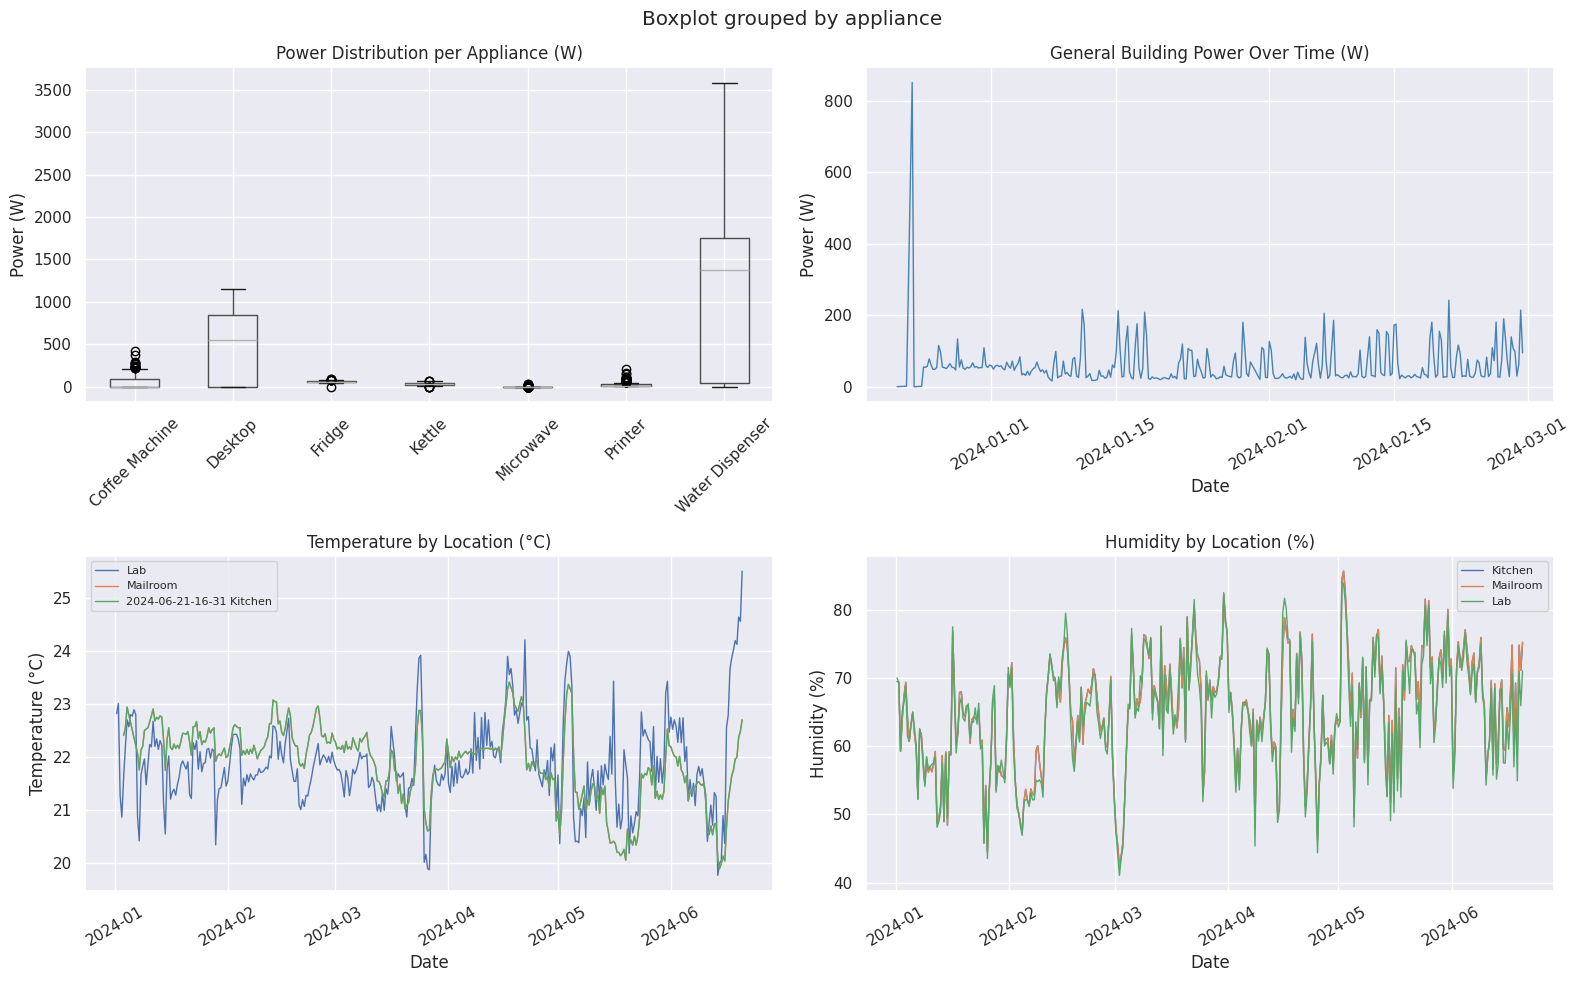

✅ Plot saved to Drive: /content/drive/MyDrive/smart_building_anomaly/outputs/plots/sprint1_overview.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sharjah 2024 Smart Building — Sprint 1 Data Overview", fontsize=14, fontweight="bold")

ax1 = axes[0, 0]
appliances = df_power[df_power["appliance"] != "GENERAL"]
if not appliances.empty:
    appliances.boxplot(column="power_W", by="appliance", ax=ax1, rot=45)
ax1.set_title("Power Distribution per Appliance (W)")
ax1.set_xlabel("")
ax1.set_ylabel("Power (W)")

ax2 = axes[0, 1]
gen = df_power[df_power["appliance"] == "GENERAL"].copy()
if not gen.empty:
    ax2.plot(gen["timestamp"], gen["power_W"], color="steelblue", linewidth=1)
ax2.set_title("General Building Power Over Time (W)")
ax2.set_xlabel("Date")
ax2.set_ylabel("Power (W)")
ax2.tick_params(axis="x", rotation=30)

ax3 = axes[1, 0]
for loc in df_temp["location"].unique():
    sub = df_temp[df_temp["location"] == loc]
    ax3.plot(sub["timestamp"], sub["temp_C"], label=loc, linewidth=1)
ax3.set_title("Temperature by Location (°C)")
ax3.set_xlabel("Date")
ax3.set_ylabel("Temperature (°C)")
ax3.legend(fontsize=8)
ax3.tick_params(axis="x", rotation=30)

ax4 = axes[1, 1]
for loc in df_humidity["location"].unique():
    sub = df_humidity[df_humidity["location"] == loc]
    ax4.plot(sub["timestamp"], sub["humidity_pct"], label=loc, linewidth=1)
ax4.set_title("Humidity by Location (%)")
ax4.set_xlabel("Date")
ax4.set_ylabel("Humidity (%)")
ax4.legend(fontsize=8)
ax4.tick_params(axis="x", rotation=30)

plt.tight_layout()
plot_path = f"{PROJECT_ROOT}/outputs/plots/sprint1_overview.png"
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved to Drive: {plot_path}")


Per-Appliance Record Count Table

In [16]:
summary = df_power.groupby("appliance").agg(
    records=("power_W", "count"),
    mean_power_W=("power_W", "mean"),
    max_power_W=("power_W", "max"),
    min_power_W=("power_W", "min"),
    std_power_W=("power_W", "std")
).round(2).reset_index().sort_values("mean_power_W", ascending=False)

print("📋 Per-Appliance Summary:")
print(summary.to_string(index=False))

📋 Per-Appliance Summary:
      appliance  records  mean_power_W  max_power_W  min_power_W  std_power_W
Water Dispenser      177       1077.72      3585.00         0.00       799.03
        Desktop      158        442.37      1151.33         0.00       368.85
        GENERAL      320         60.04       850.50         0.00        62.95
         Fridge      360         59.32        88.60         0.00         8.17
 Coffee Machine      338         46.11       427.24         0.23        79.70
         Kettle      329         33.38        68.44         0.00        11.61
        Printer      355         25.87       211.09        11.76        25.07
      Microwave      341          3.15        28.55         1.00         4.47
